In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

In [3]:
df=pd.read_csv("Final_Augmented_dataset_Diseases_and_Symptoms.csv")

In [4]:
df.head()

,diseases,anxiety and nervousness,depression,shortness of breath,depressive or psychotic symptoms,sharp chest pain,dizziness,insomnia,abnormal involuntary movements,chest tightness,...,stuttering or stammering,problems with orgasm,nose deformity,lump over jaw,sore in nose,hip weakness,back swelling,ankle stiffness or tightness,ankle weakness,neck weakness
0,panic disorder,1,0,1,1,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
1,panic disorder,0,0,1,1,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
2,panic disorder,1,1,1,1,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
3,panic disorder,1,0,0,1,0,1,1,1,0,...,0,0,0,0,0,0,0,0,0,0
4,panic disorder,1,1,0,0,0,0,1,1,1,...,0,0,0,0,0,0,0,0,0,0


In [5]:
df.tail()

,diseases,anxiety and nervousness,depression,shortness of breath,depressive or psychotic symptoms,sharp chest pain,dizziness,insomnia,abnormal involuntary movements,chest tightness,...,stuttering or stammering,problems with orgasm,nose deformity,lump over jaw,sore in nose,hip weakness,back swelling,ankle stiffness or tightness,ankle weakness,neck weakness
246940,open wound of the nose,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
246941,open wound of the nose,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
246942,open wound of the nose,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
246943,open wound of the nose,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
246944,open wound of the nose,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [6]:
df.isnull().sum()

diseases                            0
anxiety and nervousness             0
depression                          0
shortness of breath                 0
depressive or psychotic symptoms    0
                                   ..
hip weakness                        0
back swelling                       0
ankle stiffness or tightness        0
ankle weakness                      0
neck weakness                       0
Length: 378, dtype: int64

In [7]:
df.shape

(246945, 378)

In [8]:
df.duplicated().sum()

np.int64(57298)

In [10]:
df.drop_duplicates(inplace=True)

In [11]:
df.columns

Index(['diseases', 'anxiety and nervousness', 'depression',
       'shortness of breath', 'depressive or psychotic symptoms',
       'sharp chest pain', 'dizziness', 'insomnia',
       'abnormal involuntary movements', 'chest tightness',
       ...
       'stuttering or stammering', 'problems with orgasm', 'nose deformity',
       'lump over jaw', 'sore in nose', 'hip weakness', 'back swelling',
       'ankle stiffness or tightness', 'ankle weakness', 'neck weakness'],
      dtype='object', length=378)

In [12]:
df.shape

(189647, 378)

In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 189647 entries, 0 to 246944
Columns: 378 entries, diseases to neck weakness
dtypes: int64(377), object(1)
memory usage: 548.4+ MB


In [15]:
df.describe()

,anxiety and nervousness,depression,shortness of breath,depressive or psychotic symptoms,sharp chest pain,dizziness,insomnia,abnormal involuntary movements,chest tightness,palpitations,...,stuttering or stammering,problems with orgasm,nose deformity,lump over jaw,sore in nose,hip weakness,back swelling,ankle stiffness or tightness,ankle weakness,neck weakness
count,189647.000000,189647.000000,189647.000000,189647.000000,189647.000000,189647.000000,189647.000000,189647.000000,189647.000000,189647.000000,...,189647.0,189647.0,189647.0,189647.0,189647.000000,189647.0,189647.0,189647.0,189647.000000,189647.0
mean,0.037607,0.041398,0.085923,0.058672,0.096780,0.066945,0.038714,0.038883,0.038319,0.024219,...,0.0,0.0,0.0,0.0,0.001334,0.0,0.0,0.0,0.000095,0.0
std,0.190244,0.199209,0.280251,0.235011,0.295658,0.249928,0.192913,0.193316,0.191965,0.153728,...,0.0,0.0,0.0,0.0,0.036500,0.0,0.0,0.0,0.009742,0.0
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,0.0,0.0,0.0,0.0,1.000000,0.0,0.0,0.0,1.000000,0.0


In [16]:
top_100=df["diseases"].value_counts().head(100).index
df=df[df["diseases"].isin(top_100)]

In [17]:
x=df.drop('diseases',axis=1)
y = df["diseases"]

In [18]:
from sklearn.model_selection import train_test_split
X_train , X_test , y_train , y_test = train_test_split(x , y, test_size = 0.20 , random_state = 42)

In [19]:
from sklearn.ensemble import RandomForestClassifier
model=RandomForestClassifier(n_estimators=1000,max_depth=20,random_state=42,n_jobs=-1)

In [20]:
model.fit(X_train,y_train)

,n_estimators,1000
,criterion,'gini'
,max_depth,20
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [21]:
estimator = model.estimators_[0]

In [22]:
y_pred=model.predict(X_test)
y_pred

array(['carpal tunnel syndrome', 'degenerative disc disease',
       'heart attack', ..., 'spontaneous abortion', 'vaginal cyst',
       'complex regional pain syndrome'], shape=(19218,), dtype=object)

In [24]:
from sklearn.metrics import accuracy_score
accuracy=accuracy_score(y_test,y_pred)
print("Accuracy:",accuracy)

Accuracy: 0.8581017795816422


In [25]:
from sklearn.metrics import classification_report
print(classification_report(y_pred,y_test))

                                              precision    recall  f1-score   support

                           actinic keratosis       0.68      0.97      0.80       110
                         acute bronchiolitis       0.91      0.98      0.94       201
                            acute bronchitis       0.70      0.70      0.70       231
                          acute bronchospasm       0.31      0.82      0.45        65
                         acute kidney injury       0.94      0.99      0.96       151
                          acute pancreatitis       0.83      0.99      0.91       212
                             acute sinusitis       0.76      0.91      0.83       148
                                     allergy       0.91      1.00      0.95       145
                                      angina       0.88      0.99      0.93       151
                                     anxiety       0.98      0.79      0.88       284
                                appendicitis       0.

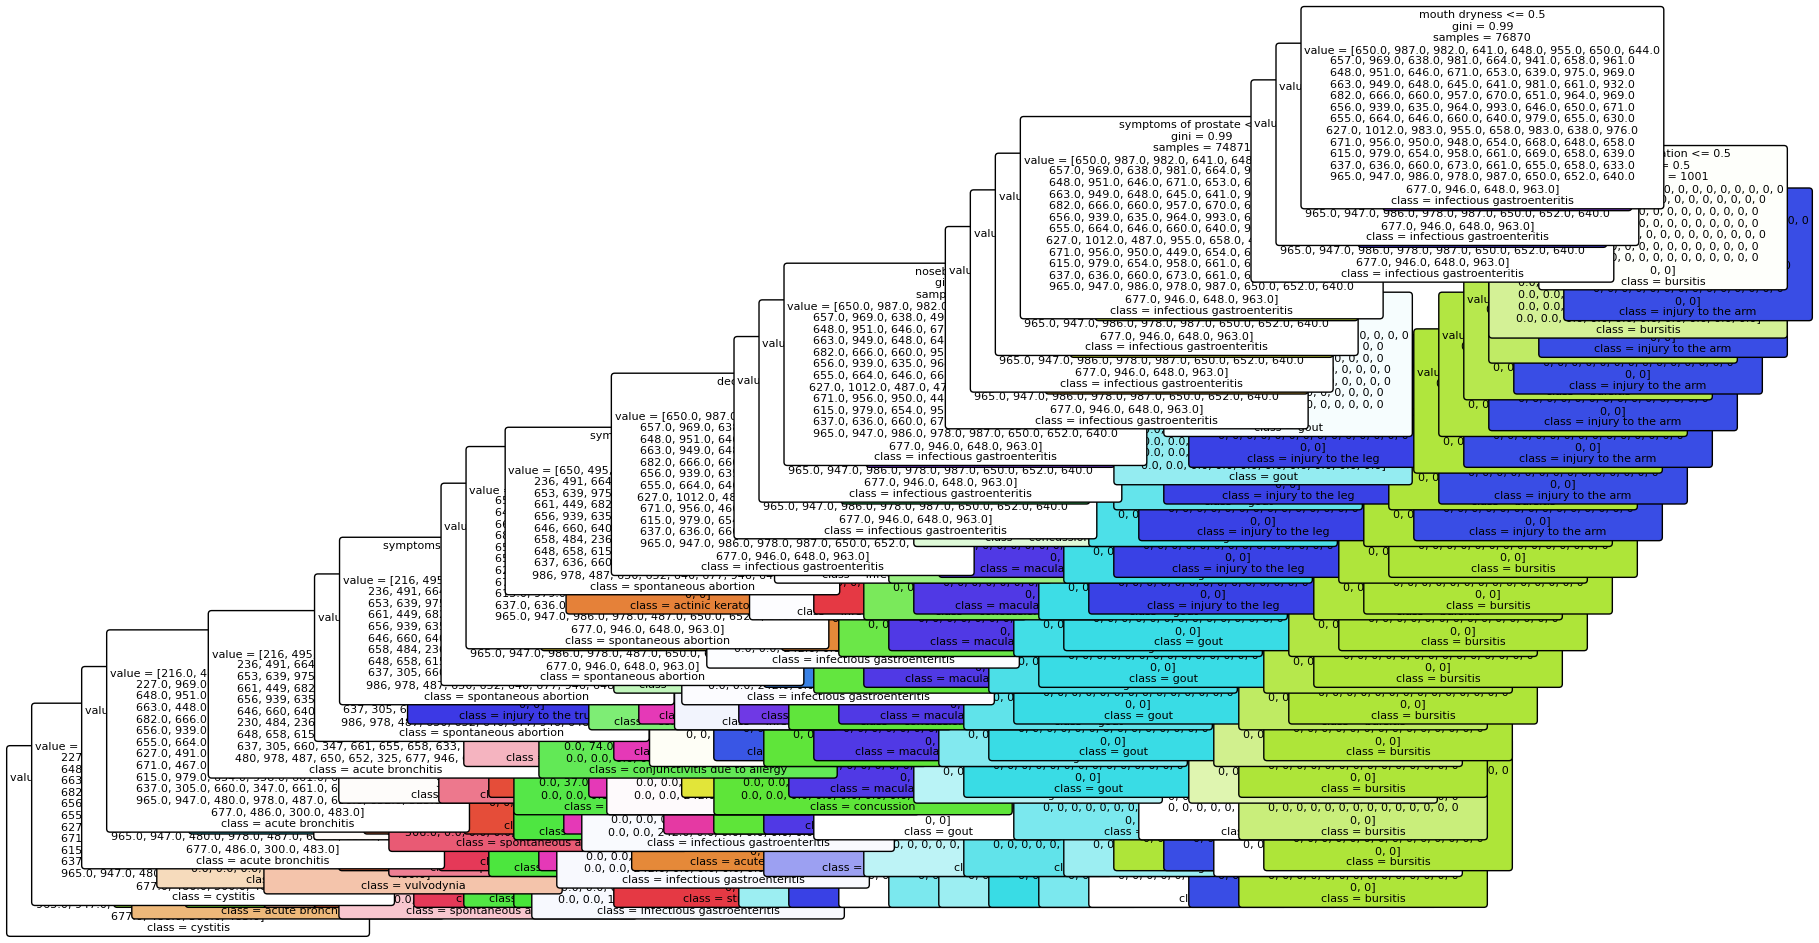

In [30]:
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
import matplotlib.pyplot as plt

dt_model = DecisionTreeClassifier(max_depth=20, random_state=42)
dt_model.fit(X_train, y_train)

plt.figure(figsize=(20,10))
tree.plot_tree(
    dt_model,
    feature_names=x.columns,
    class_names=[str(i) for i in dt_model.classes_],
    filled=True,
    rounded=True,
    fontsize=8
)
plt.show()

In [31]:
import joblib
joblib.dump(model,"Main_Project.pkl")

['Main_Project.pkl']

In [32]:
import joblib
joblib.dump(x.columns.tolist(),"feature_names.pkl")

['feature_names.pkl']